# Linear programming: economic dispatch

Which plants run in which hour to meet demand at minimum cost. This is the template for
every other optimisation here (battery, hedging, unit commitment), so the mechanics matter.

Every idea is shown first on a **2-generator, 2-hour** problem small enough to solve in
your head, then on a real day with 5 generators and 24 hours.

**What's in here**
1. The smallest dispatch problem: variables, cost vector `c`, constraint matrix `A_eq`, bounds
2. `linprog`: solve, check `res.status`, read `res.x`, verify constraints by hand
3. Dual values = marginal prices
4. The greedy merit order by hand (same answer when hours are independent)
5. Infeasibility and a slack variable (value of lost load)
6. A function that builds the matrices for any size, checked against the hand-built toy
7. The real day: 5 generators × 24 hours
8. Ramp constraints: hours become coupled
9. LP checklist

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog, milp, LinearConstraint, Bounds, minimize
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
df.head(3)

,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83
2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21
2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71


## 1. The smallest dispatch problem

Two generators, two hours.

- nuclear: costs 12 EUR/MWh, at most 10 MW
- gas: costs 50 EUR/MWh, at most 20 MW
- demand: 8 MW in hour 0, 25 MW in hour 1

In [2]:
gens = pd.DataFrame({"cost": [12, 50], "cap": [10, 20]}, index=["nuclear", "gas"])
demand = np.array([8, 25])
print(gens)
print()
print("demand:", demand)

         cost  cap
nuclear    12   10
gas        50   20

demand: [ 8 25]


### The decision variables

One number per (generator, hour): how many MW that generator produces in that hour.
`linprog` wants them in one flat vector, so we must fix an order and stick to it.
We use **generator-major**: all hours of generator 0, then all hours of generator 1.

In [3]:
G = 2          # generators
H = 2          # hours
names = ["nuclear_h0", "nuclear_h1", "gas_h0", "gas_h1"]
order = pd.DataFrame({"generator": ["nuclear", "nuclear", "gas", "gas"], "hour": [0, 1, 0, 1]}, index=names)
order.index.name = "position in x"
order

,generator,hour
position in x,,
nuclear_h0,nuclear,0
nuclear_h1,nuclear,1
gas_h0,gas,0
gas_h1,gas,1


### The cost vector `c`

`c[i]` is the cost of one unit of variable `i`. Nuclear's cost is repeated for both of its hours,
then gas's cost for both of its hours. `np.repeat` does exactly that.

In [4]:
c = np.repeat(gens["cost"].to_numpy(), H)
pd.Series(c, index=names, name="cost per MW")

nuclear_h0    12
nuclear_h1    12
gas_h0        50
gas_h1        50
Name: cost per MW, dtype: int64

### The demand constraints `A_eq x = b_eq`

One row per hour. The row has a 1 under every variable that belongs to that hour and 0 elsewhere.
Written out by hand:

In [5]:
A_eq = np.array([[1, 0, 1, 0],      # hour 0: nuclear_h0 + gas_h0
                 [0, 1, 0, 1]])     # hour 1: nuclear_h1 + gas_h1
b_eq = demand
pd.DataFrame(A_eq, index=["hour 0", "hour 1"], columns=names)

,nuclear_h0,nuclear_h1,gas_h0,gas_h1
hour 0,1,0,1,0
hour 1,0,1,0,1


Row "hour 0" says: `1·nuclear_h0 + 0·nuclear_h1 + 1·gas_h0 + 0·gas_h1 = 8`.
Row "hour 1" says: `nuclear_h1 + gas_h1 = 25`.

In [6]:
pd.Series(b_eq, index=["hour 0", "hour 1"], name="b_eq (demand)")

hour 0     8
hour 1    25
Name: b_eq (demand), dtype: int64

### The bounds

Each variable is between 0 and the generator's capacity. One `(low, high)` pair per variable,
in the same order as `c`.

**Pitfall:** if you pass no bounds, `linprog` assumes `(0, None)` for every variable: non-negative
and unlimited. A generator with no upper bound would happily produce 1,000 MW.

In [7]:
bounds = [(0, 10), (0, 10), (0, 20), (0, 20)]
pd.DataFrame(bounds, index=names, columns=["low", "high"])

,low,high
nuclear_h0,0,10
nuclear_h1,0,10
gas_h0,0,20
gas_h1,0,20


## 2. Solve with `linprog`

`linprog` **minimises** `c @ x` subject to `A_eq @ x = b_eq` and the bounds.
The result object has `status` (0 = optimal, 2 = infeasible, 3 = unbounded), `message`,
`fun` (the objective value) and `x` (the solution).

In [8]:
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
print("status :", res.status)
print("message:", res.message)
print("cost   :", res.fun)

status : 0
message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
cost   : 966.0


### Read the solution

`res.x` is in the same order as `c`. Put the names back on it.

In [9]:
pd.Series(res.x, index=names, name="MW")

nuclear_h0     8.0
nuclear_h1    10.0
gas_h0         0.0
gas_h1        15.0
Name: MW, dtype: float64

Or reshape it into a (generator × hour) table: `reshape(G, H)` undoes the generator-major flattening.

In [10]:
dispatch = pd.DataFrame(res.x.reshape(G, H), index=gens.index, columns=["hour 0", "hour 1"])
dispatch

,hour 0,hour 1
nuclear,8.0,10.0
gas,0.0,15.0


What to notice:
- hour 0: demand 8 is fully covered by nuclear (cheapest), gas stays at 0
- hour 1: nuclear is at its 10 MW cap, gas supplies the remaining 15
- cost = 12·8 + 12·10 + 50·15 = 96 + 120 + 750 = 966, which is `res.fun`

### Verify the constraints yourself

The solver says "optimal", but *you* built `A_eq`. Multiply it out and compare with `b_eq`.

In [11]:
check = pd.DataFrame({"A_eq @ x": A_eq @ res.x, "b_eq": b_eq}, index=["hour 0", "hour 1"])
check

,A_eq @ x,b_eq
hour 0,8.0,8
hour 1,25.0,25


**Pitfall:** `linprog` minimises. To maximise, negate the cost vector. Tiny example: maximise
`3x + 2y` with `x + y <= 4`.

In [12]:
res_max = linprog(c=[-3, -2], A_ub=[[1, 1]], b_ub=[4], bounds=[(0, None), (0, None)], method="highs")
print("x, y     :", res_max.x)
print("res.fun  :", res_max.fun, "   (this is -(3x + 2y))")
print("maximum  :", -res_max.fun)

x, y     : [4. 0.]
res.fun  : -12.0    (this is -(3x + 2y))
maximum  : 12.0


## 3. Dual values = marginal prices

`res.eqlin.marginals[h]` is "how much would the total cost rise if demand in hour h rose by 1 MW".
That is the cost of the **marginal** generator, the one that would produce the extra MW.
In a merit-order market, that is the price.

In [13]:
duals = pd.Series(res.eqlin.marginals, index=["hour 0", "hour 1"], name="dual (EUR/MWh)")
pd.concat([dispatch.T, duals], axis=1)

,nuclear,gas,dual (EUR/MWh)
hour 0,8.0,0.0,12.0
hour 1,10.0,15.0,50.0


- hour 0: nuclear has spare capacity (8 of 10), so one more MW would come from nuclear at 12 → dual 12
- hour 1: nuclear is full, so one more MW would come from gas at 50 → dual 50

**Interview check:** "What would the dual be if demand in hour 1 were 30, i.e. both generators full?"
The problem would be infeasible: there is no marginal generator (see section 5).

## 4. The greedy merit order gives the same answer

When nothing links the hours together, each hour is its own problem: sort generators by cost,
fill from the cheapest until demand is met. Here it is for hour 1, step by step.

In [14]:
remaining = demand[1]
print("demand to cover:", remaining)
for g in gens.sort_values("cost").index:          # cheapest first
    take = min(gens.loc[g, "cap"], remaining)
    remaining = remaining - take
    print(f"  {g:8s} cost {gens.loc[g, 'cost']:3d}: take {take:5.1f} MW, remaining {remaining:5.1f}")

demand to cover: 25
  nuclear  cost  12: take  10.0 MW, remaining  15.0
  gas      cost  50: take  15.0 MW, remaining   0.0


Same as the LP: nuclear 10, gas 15. The LP only earns its keep once constraints couple the hours
(ramps, storage, minimum up-times).

## 5. Infeasibility and a slack variable

Raise hour-1 demand to 40 MW. Total capacity is 30 MW, so no `x` satisfies the constraints.

In [15]:
b_eq_hi = np.array([8, 40])
res_inf = linprog(c, A_eq=A_eq, b_eq=b_eq_hi, bounds=bounds, method="highs")
print("status :", res_inf.status)
print("message:", res_inf.message)
print("res.x  :", res_inf.x)

status : 2
message: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is At lower/fixed bound)
res.x  : None


Do not silently drop the constraint. Add a variable `unserved_h` per hour, with a very high cost
(the value of lost load, say 10,000 EUR/MWh). It also counts as supply in its hour. The model
stays feasible and `unserved` tells you where and how much the system is short.

In [16]:
names_s = names + ["unserved_h0", "unserved_h1"]
c_s = np.concatenate([c, [10_000, 10_000]])
A_eq_s = np.array([[1, 0, 1, 0, 1, 0],
                   [0, 1, 0, 1, 0, 1]])
bounds_s = bounds + [(0, None), (0, None)]
pd.DataFrame(A_eq_s, index=["hour 0", "hour 1"], columns=names_s)

,nuclear_h0,nuclear_h1,gas_h0,gas_h1,unserved_h0,unserved_h1
hour 0,1,0,1,0,1,0
hour 1,0,1,0,1,0,1


In [17]:
res_s = linprog(c_s, A_eq=A_eq_s, b_eq=b_eq_hi, bounds=bounds_s, method="highs")
print("status:", res_s.status)
pd.Series(res_s.x, index=names_s, name="MW")

status: 0


nuclear_h0      8.0
nuclear_h1     10.0
gas_h0          0.0
gas_h1         20.0
unserved_h0     0.0
unserved_h1    10.0
Name: MW, dtype: float64

10 MW unserved in hour 1, and the hour-1 dual is now 10,000 (the marginal "generator" is lost load):

In [18]:
print("duals:", res_s.eqlin.marginals)

duals: [   12. 10000.]


## 6. A function that builds the matrices for any size

The same three ingredients, written generally. Build it step by step and check it reproduces the
hand-built toy exactly before trusting it on 5 × 24.

In [19]:
def build_dispatch(cost, cap, demand):
    """cost: (G,)   cap: (G, H)   demand: (H,)   -> c, A_eq, b_eq, bounds, names"""
    G, H = cap.shape
    c = np.repeat(cost, H)                       # each generator's cost, H times
    A_eq = np.tile(np.eye(H), (1, G))            # the H×H identity, repeated G times side by side
    b_eq = np.asarray(demand, dtype=float)
    bounds = [(0, ub) for ub in cap.ravel()]     # cap flattened in the same generator-major order
    names = [f"{g}_h{h}" for g in cost.index for h in range(H)]
    return c, A_eq, b_eq, bounds, names

cap_toy = np.array([[10, 10],
                    [20, 20]])                   # (G, H): each generator's cap in each hour
c2, A2, b2, bounds2, names2 = build_dispatch(gens["cost"], cap_toy, demand)
print("c      :", c2)
print("names  :", names2)
pd.DataFrame(A2, index=["hour 0", "hour 1"], columns=names2)

c      : nuclear    12
nuclear    12
gas        50
gas        50
Name: cost, dtype: int64
names  : ['nuclear_h0', 'nuclear_h1', 'gas_h0', 'gas_h1']


,nuclear_h0,nuclear_h1,gas_h0,gas_h1
hour 0,1.0,0.0,1.0,0.0
hour 1,0.0,1.0,0.0,1.0


In [20]:
print("same c    :", np.array_equal(c2, c))
print("same A_eq :", np.array_equal(A2, A_eq))
print("same bounds:", bounds2 == bounds)

same c    : True
same A_eq : True
same bounds: True


## 7. The real day: 5 generators × 24 hours

A cold winter day, at 10% of national demand. Wind costs nothing but its capacity depends on the
hourly wind speed (nothing below 3 m/s, full output at 12 m/s).

In [21]:
day = "2023-01-24"
demand24 = (df.loc[day, "consumption_mwh"] * 0.10).to_numpy()
wind_ms = df.loc[day, "wind_ms"].to_numpy()
wind_avail = np.clip((wind_ms - 3) / (12 - 3), 0, 1)

gens5 = pd.DataFrame({
    "cost": [12, 0, 65, 85, 160],
    "cap":  [900, 1500, 600, 1400, 500],
}, index=["nuclear", "wind", "imports", "ccgt", "ocgt"])
print(gens5)
print()
print("demand MW, first 6 hours:", demand24[:6].round(0))
print("wind availability, first 6 hours:", wind_avail[:6].round(2))

         cost   cap
nuclear    12   900
wind        0  1500
imports    65   600
ccgt       85  1400
ocgt      160   500

demand MW, first 6 hours: [3140. 2968. 2934. 2912. 2823. 2909.]
wind availability, first 6 hours: [0.05 0.05 0.28 0.37 0.23 0.21]


In [22]:
G5, H24 = 5, 24
cap5 = np.repeat(gens5["cap"].to_numpy()[:, None], H24, axis=1)      # (5, 24), same cap every hour
cap5[1] = gens5.loc["wind", "cap"] * wind_avail                       # except wind
pd.DataFrame(cap5, index=gens5.index, columns=range(H24)).iloc[:, :6]

,0,1,2,3,4,5
nuclear,900,900,900,900,900,900
wind,78,75,413,556,343,308
imports,600,600,600,600,600,600
ccgt,1400,1400,1400,1400,1400,1400
ocgt,500,500,500,500,500,500


In [23]:
c5, A5, b5, bounds5, names5 = build_dispatch(gens5["cost"], cap5, demand24)
print("c shape   :", c5.shape)
print("A_eq shape:", A5.shape, "  (24 hour-rows × 120 variables)")
print("bounds    :", len(bounds5))
pd.DataFrame(A5, columns=names5).iloc[:3, :6]      # first 3 hour-rows, first 6 variables (nuclear h0..h5)

c shape   : (120,)
A_eq shape: (24, 120)   (24 hour-rows × 120 variables)
bounds    : 120


,nuclear_h0,nuclear_h1,nuclear_h2,nuclear_h3,nuclear_h4,nuclear_h5
0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0


Row 0 has a 1 under `nuclear_h0`, row 1 under `nuclear_h1`, and so on: each hour-row picks out that hour
of every generator.

In [24]:
res5 = linprog(c5, A_eq=A5, b_eq=b5, bounds=bounds5, method="highs")
print("status :", res5.status, "|", res5.message)
print("cost   : EUR %.0f" % res5.fun)

status : 0 | Optimization terminated successfully. (HiGHS Status 7: Optimal)
cost   : EUR 3682378


In [25]:
dispatch5 = pd.DataFrame(res5.x.reshape(G5, H24).T, columns=gens5.index)
dispatch5.index.name = "hour"
dispatch5["demand"] = demand24
dispatch5.round(0).iloc[[0, 6, 12, 18, 23]]

,nuclear,wind,imports,ccgt,ocgt,demand
hour,,,,,,
0,900.0,78.0,600.0,1400.0,162.0,3140.0
6,900.0,648.0,600.0,954.0,0.0,3102.0
12,900.0,970.0,600.0,1026.0,0.0,3496.0
18,900.0,943.0,600.0,1400.0,142.0,3985.0
23,900.0,804.0,600.0,899.0,0.0,3203.0


In [26]:
supply = dispatch5[gens5.index].sum(axis=1)
print("max |supply - demand| over 24 hours:", np.abs(supply - demand24).max().round(6))

max |supply - demand| over 24 hours: 0.0


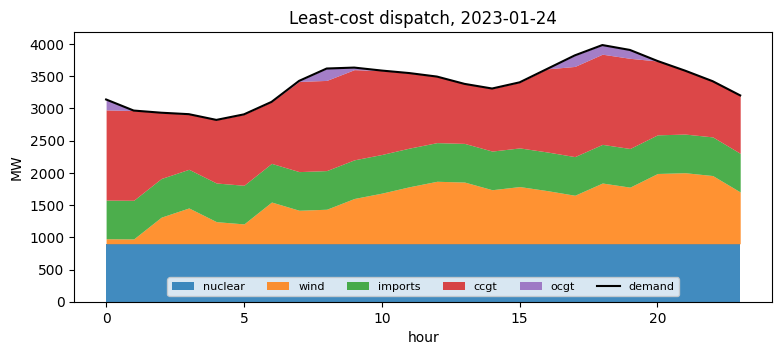

In [27]:
ax = dispatch5[gens5.index].plot.area(figsize=(9, 3.5), linewidth=0, alpha=0.85)
dispatch5["demand"].plot(ax=ax, color="k", linewidth=1.5, label="demand")
ax.set_ylabel("MW"); ax.set_title(f"Least-cost dispatch, {day}"); ax.legend(ncol=6, fontsize=8)
plt.show()

### Duals on the real day

For each hour, the dual should equal the cost of the generator that is running but not at its cap.

In [28]:
price5 = pd.Series(res5.eqlin.marginals, index=dispatch5.index, name="dual")
for h in [0, 3, 8, 12, 17, 18]:
    out = dispatch5.loc[h, gens5.index]
    partial = out[(out > 1e-6) & (out < cap5[:, h] - 1e-6)].index.tolist()   # running below cap
    print(f"hour {h:2d}: dual {price5[h]:6.1f}   running-below-cap: {partial}")

hour  0: dual  160.0   running-below-cap: ['ocgt']
hour  3: dual   85.0   running-below-cap: ['ccgt']
hour  8: dual  160.0   running-below-cap: ['ocgt']
hour 12: dual   85.0   running-below-cap: ['ccgt']
hour 17: dual  160.0   running-below-cap: ['ocgt']
hour 18: dual  160.0   running-below-cap: ['ocgt']


**Interview check:** "why is the price 85 at hour 3 and 160 at hour 18?" Because CCGT is the marginal
unit at night and OCGT is needed at the evening peak.

### The greedy merit order, all 24 hours

The same loop as section 4, once per hour. It must match the LP exactly here.

In [29]:
greedy = np.zeros((G5, H24))
for h in range(H24):
    remaining = demand24[h]
    for gi in np.argsort(gens5["cost"].to_numpy(), kind="stable"):
        take = min(cap5[gi, h], remaining)
        greedy[gi, h] = take
        remaining = remaining - take
print("max |LP - greedy|:", np.abs(greedy - res5.x.reshape(G5, H24)).max().round(6))

max |LP - greedy|: 0.0


## 8. Ramp constraints: hours become coupled

A plant cannot jump from 0 to full output in an hour. `|x[g,h] - x[g,h-1]| <= ramp_g` is two
`<=` rows per hour: `x[g,h] - x[g,h-1] <= ramp` and `x[g,h-1] - x[g,h] <= ramp`.

Toy: 3 hours, demand [8, 20, 25], gas can ramp at most **7 MW per hour**.
Without the ramp, gas would produce 0, 10, 15. From 0 it can only reach 7 in hour 1, so it
must already be running in hour 0 (displacing cheaper nuclear) to be ready for hour 1.

In [30]:
demand3 = np.array([8, 20, 25])
cap3 = np.array([[10, 10, 10],
                 [20, 20, 20]])
c3, A3, b3, bounds3, names3 = build_dispatch(gens["cost"], cap3, demand3)
print(names3)

['nuclear_h0', 'nuclear_h1', 'nuclear_h2', 'gas_h0', 'gas_h1', 'gas_h2']


`A_ub` rows are always `<=`. The four ramp rows for gas (hours 0→1 and 1→2, up and down):

In [31]:
A_ub3 = np.array([[0, 0, 0, -1,  1,  0],     # gas_h1 - gas_h0 <= 7
                  [0, 0, 0,  1, -1,  0],     # gas_h0 - gas_h1 <= 7
                  [0, 0, 0,  0, -1,  1],     # gas_h2 - gas_h1 <= 7
                  [0, 0, 0,  0,  1, -1]])    # gas_h1 - gas_h2 <= 7
b_ub3 = np.array([7, 7, 7, 7])
pd.DataFrame(A_ub3, index=["up 0->1", "down 0->1", "up 1->2", "down 1->2"], columns=names3)

,nuclear_h0,nuclear_h1,nuclear_h2,gas_h0,gas_h1,gas_h2
up 0->1,0,0,0,-1,1,0
down 0->1,0,0,0,1,-1,0
up 1->2,0,0,0,0,-1,1
down 1->2,0,0,0,0,1,-1


In [32]:
res_free = linprog(c3, A_eq=A3, b_eq=b3, bounds=bounds3, method="highs")
res_ramp = linprog(c3, A_ub=A_ub3, b_ub=b_ub3, A_eq=A3, b_eq=b3, bounds=bounds3, method="highs")
print("status:", res_ramp.status)
pd.DataFrame({"no ramp": res_free.x, "with ramp": res_ramp.x}, index=names3)

status: 0


,no ramp,with ramp
nuclear_h0,8.0,5.0
nuclear_h1,10.0,10.0
nuclear_h2,10.0,10.0
gas_h0,0.0,3.0
gas_h1,10.0,10.0
gas_h2,15.0,15.0


With the ramp, gas runs 3 MW in hour 0 (so it can reach 10 in hour 1), and nuclear drops to 5.
The cost goes up by 3 MW × (50 − 12) = 114, because 3 MW of cheap nuclear were swapped for gas in hour 0:

In [33]:
print("cost no ramp  :", res_free.fun)
print("cost with ramp:", res_ramp.fun)
print("duals no ramp  :", res_free.eqlin.marginals)
print("duals with ramp:", res_ramp.eqlin.marginals)

cost no ramp  : 1586.0
cost with ramp: 1700.0
duals no ramp  : [12. 50. 50.]
duals with ramp: [12. 88. 50.]


The hour-1 dual is 88, not 50. One more MW in hour 1 must come from gas (50), but gas can only get
there by also running one more MW in hour 0, where it displaces nuclear (50 − 12 = 38 extra).
50 + 38 = 88: in a coupled problem the dual mixes the marginal unit with the constraint it tightens.

**Interview check:** "the price is 105 but no unit costs 105 — is the LP wrong?" No: in a coupled
problem the dual is the cost of the marginal unit *plus* the cost of the constraints it tightens.

### Ramps on the real day

The same rows, built in a loop over generators. `D` is the difference matrix that turns
`x[g, 0..23]` into `x[g,h] - x[g,h-1]`.

In [34]:
D = np.eye(H24) - np.eye(H24, k=-1)     # row h: +1 at h, -1 at h-1
D = D[1:]                               # drop row 0 (there is no hour -1)
pd.DataFrame(D[:3, :5])                 # first 3 rows, first 5 columns

,0,1,2,3,4
0,-1.0,1.0,0.0,0.0,0.0
1,0.0,-1.0,1.0,0.0,0.0
2,0.0,0.0,-1.0,1.0,0.0


In [35]:
ramp = pd.Series({"nuclear": 50, "imports": 200, "ccgt": 250})    # MW per hour; wind and ocgt unconstrained
rows, rhs = [], []
for gname in ramp.index:
    gi = gens5.index.get_loc(gname)
    block = np.zeros((H24 - 1, G5 * H24))
    block[:, gi * H24:(gi + 1) * H24] = D          # this generator's columns
    rows.append(block);  rhs.append(np.full(H24 - 1, ramp[gname]))    # up
    rows.append(-block); rhs.append(np.full(H24 - 1, ramp[gname]))    # down
A_ub5 = np.vstack(rows); b_ub5 = np.concatenate(rhs)
print("A_ub shape:", A_ub5.shape, "  (3 generators × 23 transitions × 2 directions)")

A_ub shape: (138, 120)   (3 generators × 23 transitions × 2 directions)


In [36]:
res5r = linprog(c5, A_ub=A_ub5, b_ub=b_ub5, A_eq=A5, b_eq=b5, bounds=bounds5, method="highs")
print("status:", res5r.status)
print("cost without ramps: %.0f   with ramps: %.0f   (+%.2f%%)" % (res5.fun, res5r.fun, 100 * (res5r.fun / res5.fun - 1)))
print("ramp rows satisfied:", (A_ub5 @ res5r.x <= b_ub5 + 1e-6).all())
disp5r = pd.DataFrame(res5r.x.reshape(G5, H24).T, columns=gens5.index)
pd.DataFrame({"price no ramp": price5.round(1), "price ramp": np.round(res5r.eqlin.marginals, 1),
              "ccgt no ramp": dispatch5["ccgt"].round(0), "ccgt ramp": disp5r["ccgt"].round(0)}).iloc[14:22]

status: 0
cost without ramps: 3682378   with ramps: 3689977   (+0.21%)
ramp rows satisfied: True


,price no ramp,price ramp,ccgt no ramp,ccgt ramp
14,85.0,85.0,971.0,971.0
15,85.0,65.0,1018.0,1040.0
16,85.0,105.0,1290.0,1290.0
17,160.0,160.0,1400.0,1400.0
18,160.0,160.0,1400.0,1400.0
19,160.0,160.0,1400.0,1400.0
20,85.0,65.0,1147.0,1150.0
21,85.0,85.0,985.0,985.0


## 9. LP checklist

1. Write the problem in words: decision, objective, each constraint, units.
2. Fix a variable order and write the 2×2 case by hand; check the general builder reproduces it.
3. `linprog` minimises; negate `c` to maximise. `A_ub` rows are `<=`; multiply a `>=` row by −1.
4. Default bounds are `(0, None)`: state free or capped variables explicitly.
5. Always print `res.status` and `res.message` before using `res.x`.
6. Verify `A_eq @ x` against `b_eq` yourself.
7. Read the duals and ask whether each one is the cost of a real marginal unit.
8. Infeasible → add a penalised slack and look where it is used. Unbounded → look for a sign error.
9. Reproduce the simple case with a greedy loop before trusting the general LP.